In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.shape

(20640, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [5]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Sayısal sütunlar:")
print(num_cols)

print("\nKategorik sütunlar:")
print(cat_cols)

Sayısal sütunlar:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

Kategorik sütunlar:
Index(['ocean_proximity'], dtype='object')


In [6]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

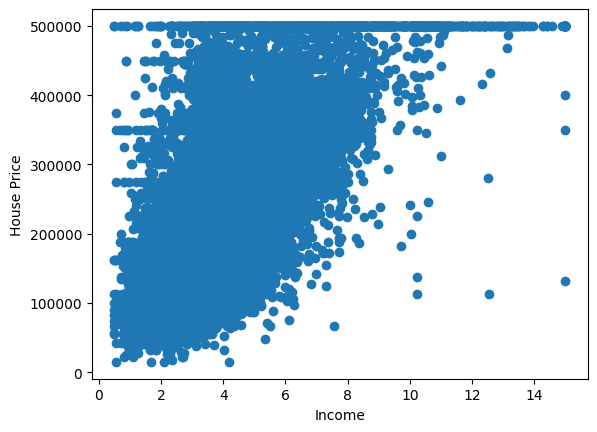

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Income")
plt.ylabel("House Price")
plt.show()

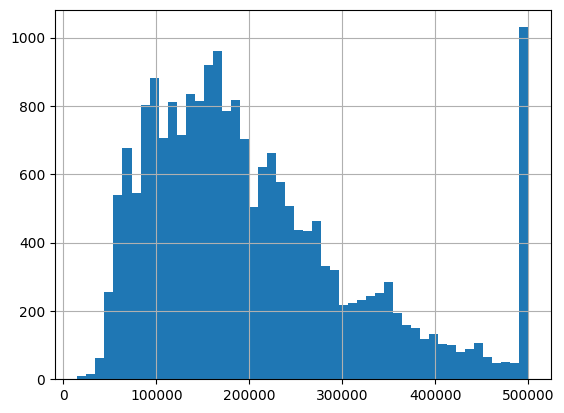

In [8]:
df["median_house_value"].hist(bins=50)
plt.show()

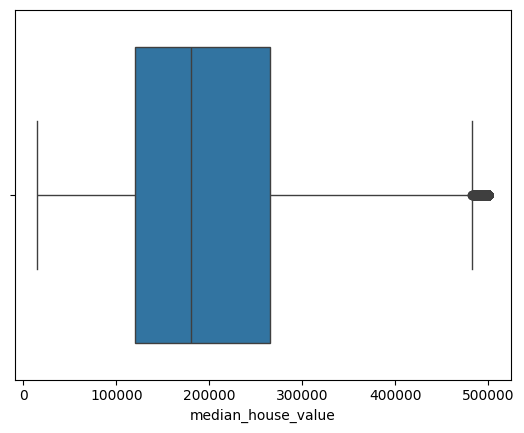

In [9]:
import seaborn as sns


sns.boxplot(x=df["median_house_value"])
plt.show()

In [10]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [11]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [12]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)


Eğitim seti boyutu: (16512, 12)
Test seti boyutu: (4128, 12)


In [14]:
numeric_features_normal = [
    'longitude',
    'latitude',
    'housing_median_age',
    'median_income',
    'rooms_per_household',
    'population_per_household',
    'bedrooms_per_room'
]

numeric_features_skewed = [
    'total_rooms',
    'total_bedrooms',
    'population',
    'households'
]

categorical_features = ['ocean_proximity']

In [15]:
print("\nNormal Sayısal Özellikler:", numeric_features_normal)
print("Çarpık Sayısal Özellikler:", numeric_features_skewed)
print("Kategorik Özellikler:", categorical_features)



Normal Sayısal Özellikler: ['longitude', 'latitude', 'housing_median_age', 'median_income', 'rooms_per_household', 'population_per_household', 'bedrooms_per_room']
Çarpık Sayısal Özellikler: ['total_rooms', 'total_bedrooms', 'population', 'households']
Kategorik Özellikler: ['ocean_proximity']


In [22]:
numeric_transformer_normal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [21]:
skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('logtransform', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ('scaler', StandardScaler())
    ])

In [24]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_normal', numeric_transformer_normal, numeric_features_normal),
        ('num_skewed', skewed_transformer, numeric_features_skewed),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline oluşturuldu.")

Preprocessing pipeline oluşturuldu.


In [25]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


In [26]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_normal', ...), ('num_skewed', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [27]:
predictions = model.predict(X_test)

In [28]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 67117.48557995073
R2: 0.656232752875205


In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

print("Modeller test ediliyor...")


Modeller test ediliyor...


In [30]:
for model_name, model in models.items():
    
    full_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])
    
    scores = cross_val_score(
        full_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -scores
    results[model_name] = rmse_scores.mean()
    
    print(f"{model_name}: RMSE = {rmse_scores.mean():.2f}")

Linear Regression: RMSE = 66282.43
Random Forest: RMSE = 50250.11
Gradient Boosting: RMSE = 52642.99


In [31]:
tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

print("Hyperparameter tuning başlıyor...")

grid_search = GridSearchCV(
    tune_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Optimizasyon tamamlandı!")
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV RMSE:", -grid_search.best_score_)

final_pipeline = grid_search.best_estimator_

Hyperparameter tuning başlıyor...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Optimizasyon tamamlandı!
En iyi parametreler: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
En iyi CV RMSE: 50113.06185649619


In [38]:
y_pred = final_pipeline.predict(X_test)
y_pred = final_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("📊 FINAL MODEL SONUÇLARI")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

📊 FINAL MODEL SONUÇLARI
RMSE: 49443.19
R2: 0.8134


In [41]:
def add_features(X):
    X = X.copy()
    
    X["rooms_per_household"] = X["total_rooms"] / X["households"]
    X["bedrooms_per_room"] = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"] / X["households"]
    
    return X

In [42]:
feature_engineering = FunctionTransformer(add_features)

In [43]:
full_pipeline = Pipeline([
    ("feature_engineering", feature_engineering),  # 🔥 YENİ
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        min_samples_leaf=2
    ))
])

In [44]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)